In [2]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)

<h4>Loading Prepared data</h4>

In [3]:
train_data = pd.read_csv('malaria_train.csv')
val_df = pd.read_csv('malaria_val.csv')
test_df = pd.read_csv('malaria_test.csv')

X_train = train_data.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_train = train_data['Malaria_Positive'].values.astype(np.float32)

X_val = val_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_val = val_df['Malaria_Positive'].values.astype(np.float32)

X_test = test_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_test = test_df['Malaria_Positive'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")


Train: (560, 15)
Val: (120, 15)
Test: (120, 15)
Number of features: 15


In [25]:
# Understanding the data
with open('malaria_train.json') as f:
    metadata = json.load(f)


    
total = {key: [row[key] for row in metadata] for key in metadata[0]}



print(total.keys())
print(total['Age'][:10])
print(len(total['Age']))
df = pd.DataFrame(total)

dict_keys(['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea', 'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count', 'Vulnerable_Age', 'Malaria_Positive'])
[-0.0971515477, 0.1797178686, -1.0661945343, 0.664239347, -0.1663689017, -0.8585424423, 0.664239347, 1.0103261471, -0.3740209639, -0.3048036098]
560


In [5]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    # block 1
    x = keras.layers.Dense(128, kernel_regularizer = keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    #block 2
    x = keras.layers.Dense(64, kernel_regularizer = keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    #output a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)
    return keras.Model(inputs, outputs, name='MalariaANN')

In [6]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "MalariaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 15)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

<h5>Cmpiling the model</h5>

In [7]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

<h5>Callbacks</h5>

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_diabetes.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = model.fit(
    X_train,y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"\Best val AUC: {max(history.history['val_auc']):.4f}")

<>:25: SyntaxWarning: invalid escape sequence '\B'
<>:25: SyntaxWarning: invalid escape sequence '\B'
C:\Users\ATZ COMPUTERS\AppData\Local\Temp\ipykernel_4812\2185311757.py:25: SyntaxWarning: invalid escape sequence '\B'
  print(f"\Best val AUC: {max(history.history['val_auc']):.4f}")


Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6054 - auc: 0.6004 - loss: 0.7028 - precision: 0.5349 - recall: 0.3948 - val_accuracy: 0.8250 - val_auc: 0.9120 - val_loss: 0.6265 - val_precision: 0.7636 - val_recall: 0.8400 - learning_rate: 5.0000e-04
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8536 - auc: 0.9201 - loss: 0.4300 - precision: 0.8756 - recall: 0.7554 - val_accuracy: 0.9417 - val_auc: 0.9903 - val_loss: 0.5027 - val_precision: 0.9216 - val_recall: 0.9400 - learning_rate: 5.0000e-04
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8929 - auc: 0.9653 - loss: 0.3350 - precision: 0.9100 - recall: 0.8240 - val_accuracy: 0.9500 - val_auc: 0.9930 - val_loss: 0.4015 - val_precision: 0.9231 - val_recall: 0.9600 - learning_rate: 5.0000e-04
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9286 - auc: 0.9806 - loss: 0.2843 - precision: 0.9488 - recall: 0.8755 - val_accuracy: 0.9500 - val_auc: 0.9931 - val_loss

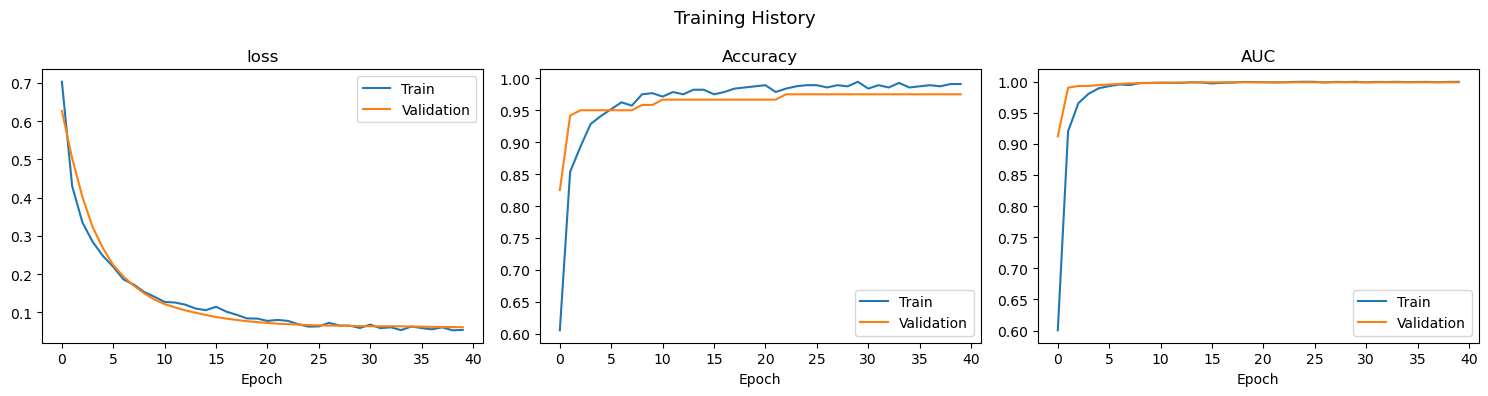

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()



In [21]:
model.load_weights('best_diabetes.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.0707
compile_metrics: 0.9917


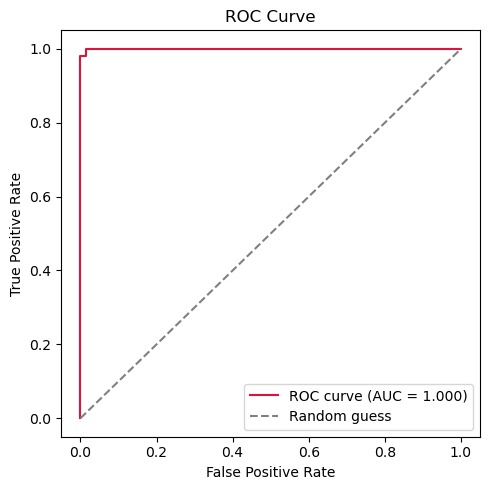

ROC-AUC: 0.9997


In [11]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, color='crimson', label = f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

              precision    recall  f1-score   support

  No Malaria       0.99      1.00      0.99        70
     Malaria       1.00      0.98      0.99        50

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



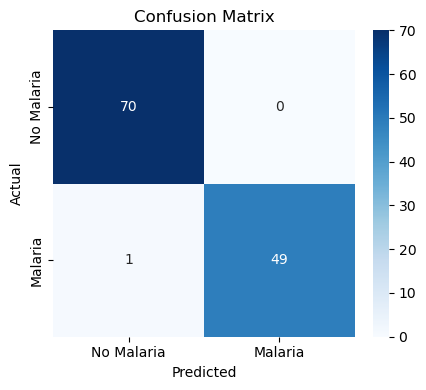

In [12]:
y_pred = (y_prob >= 0.5).astype(int)
import seaborn as sns
print(classification_report(y_test, y_pred, target_names=['No Malaria', 'Malaria']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Malaria', 'Malaria'],
           yticklabels=['No Malaria', 'Malaria'] )

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
model = keras.models.load_model('best_diabetes.keras')
#converting to dataframe
train_data = pd.read_csv('malaria_train.csv')
x_train = train_data.drop(columns=['Malaria_Positive'])

# Calculating mean and std
MEAN = x_train.mean().values
STD = x_train.std().values

def predict_patient(raw_data):

    """"
    Input: raw paient data (not scaled) in this order
    Age, 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 
    'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea',
    'High_Fever', 'Fever_x_Chills', 'Severe_Headache',
    'Symptom_Count', 'Vulnerable_Age'
    """
    
    # scaling the data 
    scaled = [(raw_data[i] - MEAN[i])/ STD[i] for i in range(len(raw_data))]
    x = np.array(scaled, dtype=np.float32).reshape(1,-1)

# predict
    prob = model.predict(x, verbose=0)[0,0]
    return{
        'probability': round(prob,4),
        'prediction' : 'Malaria' if prob >= 0.5 else 'No Malaria'
    }

# Testing the trained data withnew patient
new_patient = [25,39.2, 1, 4, 0, 0, 3, 4, 1, 0, 1, 39.2, 1, 5, 0]
result = predict_patient(new_patient)
print(f"Probability: {result['probability']:.2%}")
print(f"Prediction: {result['prediction']}")


Probability: 100.00%
Prediction: Malaria
